# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
!pip install imbalanced-learn

### 0.b Import Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "6"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [8]:
experiment_hypothesis = """
SVM with an RBF kernel and SMOTE oversampling should outperform Logistic
Regression from Experiment 5 and potentially match or beat HistGradientBoosting's
macro F1 of 0.7647.

Experiment 5 confirmed that the 5 classes are not linearly separable. SVM with
an RBF kernel addresses this directly the kernel function maps the features
into a higher dimensional space where non-linear boundaries become linear
hyperplanes. This is fundamentally different from Logistic Regression which
can only draw straight boundaries in the original feature space.

SVM is also well suited for datasets where classes overlap in feature space,
which is exactly the problem seen throughout this project. The support vectors,
 the samples closest to the decision boundary define the hyperplane, making
SVM robust to the majority of samples and focusing on the hard boundary cases.
This should help with Scurvy and Night_Blindness which overlap with other
classes.

SMOTE is retained from Experiment 5 to address the training sample shortage
for minority classes. However the key difference is that SVM's non-linear
kernel should make better use of the synthetic samples than Logistic Regression
could, since it can find boundaries in the higher dimensional space where
SMOTE samples are more separable.
"""

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [10]:
experiment_expectations = """
Target: macro F1 above 0.78 on the validation set, improving on Logistic
Regression's 0.5770 and approaching HistGradientBoosting's 0.7647.

Three ways this could go:

1. It works well (macro F1 above 0.80): The RBF kernel finds non-linear
   boundaries that separate all 5 classes cleanly. SMOTE synthetic samples
   are well utilised and Scurvy recall crosses 0.60 without precision
   collapsing as it did in Experiment 5.

2. It works partially (macro F1 between 0.70 and 0.80): SVM improves over
   Logistic Regression significantly but the overlapping feature space between
   Scurvy and Anemia remains a challenge. Macro F1 approaches but doesn't
   beat HistGradientBoosting.

3. It doesn't improve enough (macro F1 below 0.70): The RBF kernel overfits
   on the SMOTE synthetic samples similar to Logistic Regression. This would
   confirm that HistGradientBoosting is the best model for this dataset and
   no further algorithmic improvements are likely without additional real
   training data for Scurvy and Night_Blindness.
"""

In [11]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [12]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [13]:
# Shape confirmation
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution before SMOTE
print("\nClass distribution (train) before SMOTE:")
print(y_train['disease_diagnosis'].value_counts())

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train) before SMOTE:
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64


---
## D. Feature Selection


In [14]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Raw intake
    'vitamin_a_intake', 'vitamin_c_intake',
    'iron_intake', 'folate_intake', 'vitamin_b12_intake',

    # Symptom scores
    'rickets_symptom_score', 'anemia_symptom_score',

    # Engineered interaction features
    'vitamin_d_calcium_product', 'vegan_b12_risk',

    # Engineered features
    'vitamin_a_night_risk', 'scurvy_risk_index',

    # Lifestyle
    'sun_exposure_type',

    # General severity
    'symptoms_count'
]

In [15]:
feature_selection_explanations = """
16 features are selected for this experiment, trimmed from Experiment 5's 19.

The three ratio and linear features from Experiment 5, vitamin_d_ratio,
vitamin_a_ratio and scurvy_linear_score are dropped. The coefficient plot
from Experiment 5 showed these features contributed near zero signal across
all classes. For SVM specifically, irrelevant features add noise to the
kernel distance calculations and can actually hurt performance by distorting
the decision boundary in the higher dimensional space.

The core feature set is retained based on consistent performance across all
experiments. vitamin_a_intake, vitamin_c_intake and serum_vitamin_d have
ranked in the top 3 importance across every experiment and are non-negotiable.

rickets_symptom_score and anemia_symptom_score are kept, the Experiment 5
coefficient plot showed these had strong directional signals for their
respective classes, confirming they provide meaningful linear and non-linear
separation.

vitamin_a_night_risk and scurvy_risk_index are retained from Experiments 2
and 4 respectively. Both contributed positively in previous experiments and
target the two weakest classes directly.

SMOTE is applied in section E to address the class imbalance, with the
expectation that SVM's RBF kernel will make better use of the synthetic
samples than Logistic Regression could by finding non-linear boundaries
in the higher dimensional kernel space.
"""

In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>


In [17]:
# From Experiment 2
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']

# From Experiment 4
for df in [X_train, X_val, X_test]:
    df['scurvy_risk_index'] = (
        df['vitamin_c_intake'] +
        df['has_bleeding_gums'] +
        df['has_fatigue']
    )

In [18]:
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 16)
X_val_model shape:   (690, 16)
X_test_model shape:  (691, 16)


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_model, y_train.values.ravel())

print("Class distribution after SMOTE:")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt}")
print(f"\nX_train_resampled shape: {X_train_resampled.shape}")

Class distribution after SMOTE:
  Anemia: 1182
  Healthy: 1182
  Night_Blindness: 1182
  Rickets_Osteomalacia: 1182
  Scurvy: 1182

X_train_resampled shape: (5910, 16)


In [20]:
data_transformation_1_explanations = """
SMOTE is applied to the training set only, validation and test sets remain
untouched to ensure evaluation reflects real world data distribution.

The key lesson from Experiment 5 is that SMOTE with a linear model generated
noisy synthetic samples in overlapping feature regions, collapsing Scurvy
precision to 0.19. SVM with an RBF kernel should handle this better by
mapping features into a higher dimensional space, boundaries that overlap
in the original feature space may become separable in the kernel space,
making the synthetic samples more useful.

As in Experiment 5, SMOTE balances all 5 classes to 1182 samples each,
giving the model equal exposure to all diseases during training.
"""

In [21]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

In [22]:
feature_engineering_1_explanations = """
No new features are created in this experiment. The engineered features
vitamin_a_night_risk and scurvy_risk_index are recreated here from their
original formulas since each notebook loads fresh splits from CSV.
"""

In [23]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

In [25]:
algorithm_selection_explanations = """
SVM with an RBF kernel is chosen as Experiment 6 to address the non-linear
class boundaries confirmed in Experiment 5.

Logistic Regression showed that the 5 classes are not linearly separable,
macro F1 dropped to 0.5770 despite SMOTE balancing. SVM with an RBF kernel
solves this by implicitly mapping features into an infinite dimensional space
where non-linear boundaries in the original space become linear hyperplanes.
This is the key theoretical advantage over Logistic Regression.

SVM is also defined by its support vectors, the samples closest to the
decision boundary. This makes it robust to the majority of training samples
and focused on the hard boundary cases, which is exactly where Scurvy and
Night_Blindness sit relative to Anemia and Rickets.

SMOTE is retained to address the class imbalance. class_weight='balanced'
is also applied on top of SMOTE as an additional safeguard both approaches
together should give minority classes the best possible representation during
training.
"""

In [26]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [27]:
param_dist = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4],
    'class_weight': ['balanced', None]
}

In [28]:
hyperparameters_selection_explanations = """
C controls the trade-off between maximising the margin and minimising
misclassification. Lower C allows more misclassifications for a wider margin
better generalisation. Higher C fits the training data more tightly
risks overfitting on SMOTE synthetic samples. Testing from 0.1 to 100 covers
the full range.

kernel tests both RBF and polynomial. RBF is the standard choice for
non-linear boundaries and works well when the relationship between features
and classes is unknown. Polynomial tests whether a lower dimensional
non-linear mapping is sufficient.

gamma controls how far the influence of a single training sample reaches
in RBF kernel space. Low gamma means far reach smoother boundaries. High
gamma means close reach  more complex boundaries that risk overfitting.
scale and auto are standard heuristics, additional values test explicit
gamma settings.

degree only applies to polynomial kernel controls the polynomial order.

class_weight='balanced' applies additional class weighting on top of SMOTE
to give minority classes extra emphasis. Testing both balanced and None lets
the search decide whether the SMOTE balancing alone is sufficient.

All tuning uses f1_macro scoring with n_iter=20 and cv=3.
"""

In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [30]:
svm = SVC(random_state=42, probability=True)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-val macro F1: {random_search.best_score_:.4f}")

best_svm = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'degree': 4, 'class_weight': None, 'C': 100.0}
Best cross-val macro F1: 0.9070


### G.4 Model Technical Performance

In [31]:
y_val_pred = best_svm.predict(X_val_model)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.5990

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.77      0.80      0.79       215
             Healthy       0.84      0.88      0.86       253
     Night_Blindness       0.28      0.28      0.28        29
Rickets_Osteomalacia       0.78      0.73      0.76       173
              Scurvy       0.42      0.25      0.31        20

            accuracy                           0.78       690
           macro avg       0.62      0.59      0.60       690
        weighted avg       0.77      0.78      0.77       690



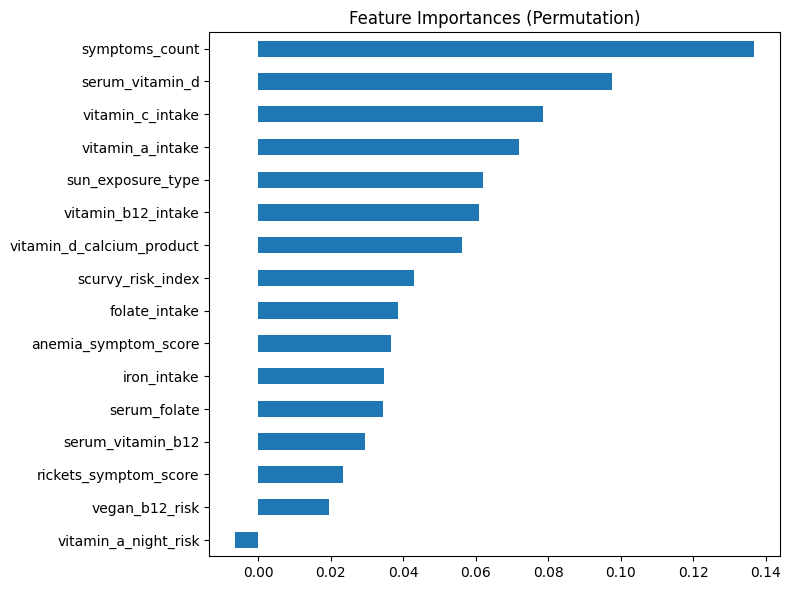

In [32]:
result = permutation_importance(
    best_svm, X_val_model, y_val,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

importances = pd.Series(result.importances_mean, index=features_list)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances (Permutation)")
plt.tight_layout()
plt.show()

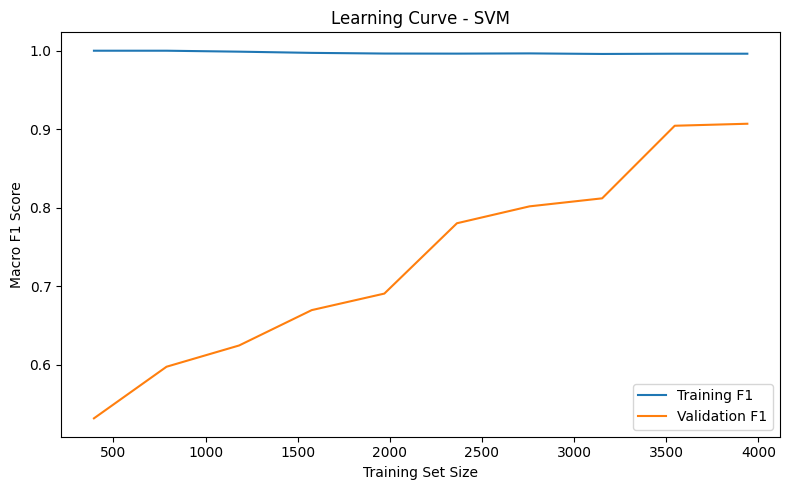

In [33]:
# Learning Curve — on resampled data
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_train_resampled, y_train_resampled,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=3, n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve - SVM')
plt.legend()
plt.tight_layout()
plt.show()

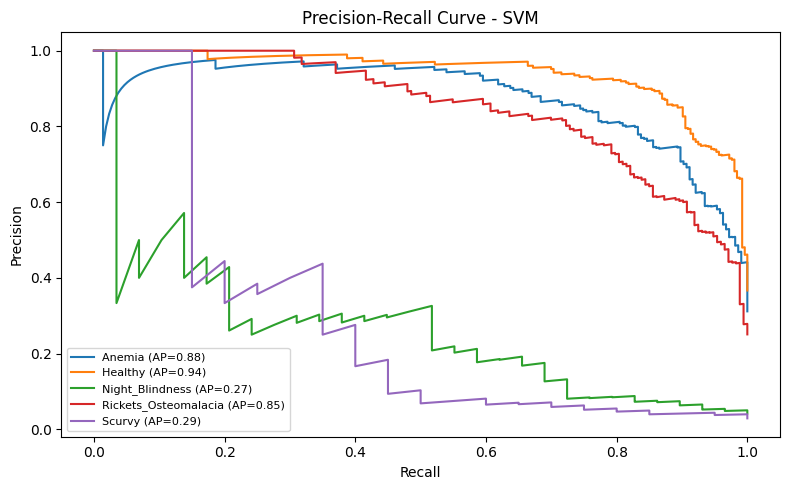

In [34]:
# Precision-Recall Curve
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_svm.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# Per-class F1
f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)
data = pd.DataFrame({'Class': classes, 'F1 Score': f1_scores.round(3)})
chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(width=400, height=300, title='Per-class F1 Score — SVM')
chart

alt.Chart(...)

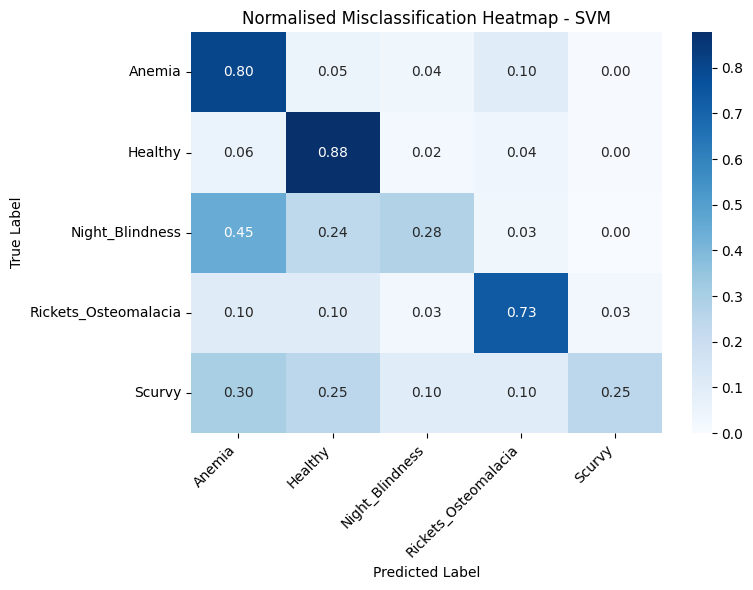

In [36]:
# Normalised Misclassification Heatmap
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Normalised Misclassification Heatmap - SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = [0.793, 0.865, 0.500, 0.734, 0.513]
rf_f1 = [0.823, 0.878, 0.667, 0.781, 0.516]
hgb_f1 = [0.840, 0.910, 0.700, 0.810, 0.560]
xgb_f1 = [0.864, 0.930, 0.643, 0.810, 0.571]
lr_f1 = [0.690, 0.870, 0.380, 0.700, 0.250]
svm_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 7,
    'Model': ['Dummy']*5 + ['Decision Tree']*5 + ['Random Forest']*5 +
             ['HistGradientBoosting']*5 + ['XGBoost']*5 +
             ['Logistic Regression']*5 + ['SVM']*5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1, *rf_f1, *hgb_f1,
                 *xgb_f1, *lr_f1, *svm_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree', 'Random Forest',
                'HistGradientBoosting', 'XGBoost', 'Logistic Regression', 'SVM'],
        range=['#95a5a6', '#e67e22', '#8e44ad', '#27ae60', '#2980b9', '#c0392b', '#f39c12']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=100,
    height=300,
    title='F1 Score Comparison: All Models'
)

print(f"Dummy Macro F1:                0.1073")
print(f"Decision Tree Macro F1:        0.6809")
print(f"Random Forest Macro F1:        0.7329")
print(f"HistGradientBoosting Macro F1: 0.7647")
print(f"XGBoost Macro F1:              0.7638")
print(f"Logistic Regression Macro F1:  0.5770")
print(f"SVM Macro F1:                  {macro_f1_val:.4f}")

chart

Dummy Macro F1:                0.1073
Decision Tree Macro F1:        0.6809
Random Forest Macro F1:        0.7329
HistGradientBoosting Macro F1: 0.7647
XGBoost Macro F1:              0.7638
Logistic Regression Macro F1:  0.5770
SVM Macro F1:                  0.5990


alt.Chart(...)

In [38]:
model_performance_explanations = """
SVM with RBF kernel achieves a macro F1 of 0.5990 on the validation set,
better than Logistic Regression's 0.5770 but significantly below all
tree-based experiments.

The learning curve tells the most important story. Training F1 stays flat
at 1.00 across all training sizes while validation F1 starts at 0.54 and
gradually climbs on the SMOTE resampled data. This massive gap confirms
the model is perfectly memorising synthetic training samples but those
boundaries do not hold on real validation data. The validation curve is
still rising steeply at full training size suggesting the model needs even
more data to generalise properly.

The precision-recall curves reveal the fundamental problem. Night_Blindness
collapsed to AP=0.27 and Scurvy to AP=0.29, both worse than the Decision
Tree baseline. Anemia at AP=0.88 and Rickets at AP=0.85 are reasonable but
the model is clearly biased toward majority classes despite SMOTE balancing.

The normalised heatmap confirms the worst Night_Blindness result across all
experiments. 45% of Night_Blindness patients are misclassified as Anemia.
The RBF kernel failed to find a boundary between these two classes in higher
dimensional space. Scurvy is scattered across all classes with only 25%
correctly identified.

The per-class F1 chart makes the failure clear. Healthy at 0.86 and Anemia
at 0.79 are reasonable but Night_Blindness at 0.28 and Scurvy at 0.31 are
the worst minority class results since the Decision Tree baseline.

The cross-val to validation gap of 0.308 is by far the largest across all
experiments, confirming that SMOTE severely inflates cross-val scores when
combined with kernel methods on overlapping feature spaces.
"""

In [39]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [40]:
business_impacts_explanations = """
SVM is the second weakest model after Logistic Regression from a clinical
standpoint, despite the impressive cross-val score of 0.9070.

Night_Blindness at 0.28 F1 is the most concerning result. Only 8 out of 29
Night_Blindness patients are correctly identified, 13 are sent down the
Anemia pathway instead. In practice this means patients with early stage
vitamin A deficiency are being treated for iron deficiency, delaying the
correct dietary intervention and risking progression to permanent vision loss.

Scurvy catching only 5 out of 20 cases at 0.25 recall is the worst Scurvy
result since the Decision Tree baseline. For a condition preventable with
vitamin C supplementation, missing 75% of cases is clinically unacceptable.

Anemia and Healthy are handled reasonably at 0.80 and 0.88 recall — the
model does well on the majority classes but completely fails on the minority
ones, which is the opposite of what SMOTE was supposed to achieve.

The fundamental problem is that SMOTE synthetic samples generated in
overlapping feature regions between Scurvy, Anemia and Night_Blindness
do not represent real patient profiles. The SVM overfits to these synthetic
boundaries during training but the boundaries don't hold on real validation
data.

Overall SVM is not suitable for this clinical task. The tree-based models -
particularly HistGradientBoosting and XGBoost remain the strongest
approaches with macro F1 around 0.76 and much more reliable minority
class performance.
"""

In [41]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [42]:
experiment_outcome = "Hypothesis Not Confirmed"

In [43]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [44]:
experiment_results_explanations = """
The hypothesis is not confirmed. SVM with RBF kernel achieved a macro F1 of
0.5990, well below the 0.78 target and below all tree-based experiments.
The cross-val score of 0.9070 was the highest across all experiments but
translated to the worst validation performance among kernel and linear models,
with a gap of 0.308.

The key finding is that SMOTE combined with kernel methods produces severely
overoptimistic cross-val estimates. When synthetic samples are evaluated in
the same distribution they were generated from, cross-val scores look
excellent. But on real validation data the synthetic boundaries don't hold,
particularly for Night_Blindness which collapsed to 0.28 F1 - the worst
single class result across all six experiments.

The RBF kernel did not resolve the Night_Blindness and Anemia overlap problem
as hypothesised. The overlap between these two classes in feature space is
too fundamental both share fatigue, weakness and similar nutritional
profiles. No kernel transformation appears sufficient to separate them
without more real training data.

Overall conclusions across all 6 experiments:

1. HistGradientBoosting (Experiment 3) is the best model at macro F1 0.7647,
   with the most balanced performance across all classes and the smallest
   cross-val to validation gap of 0.046.

2. XGBoost (Experiment 4) matches HistGradientBoosting at 0.7638 with
   perfect Scurvy precision of 1.00 but the same recall ceiling of 0.40.

3. Tree-based models consistently outperform linear and kernel methods for
   this dataset because the class boundaries are fundamentally non-linear
   and the features have complex interactions that trees exploit naturally.

4. Scurvy recall is the unresolved problem across all experiments. With
   only 95 real training samples, no algorithm can reliably learn Scurvy
   boundaries. The recommendation is to collect more real Scurvy patient
   data rather than relying on synthetic oversampling.
"""

In [45]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

#Final Model Evaluation on Test Set

In [46]:
final_model_description = """
The best model across all 6 experiments is HistGradientBoosting from
Experiment 3, selected based on the highest validation macro F1 of 0.7647
and the smallest cross-val to validation gap of 0.046.

Model configuration:
- Algorithm: HistGradientBoostingClassifier
- class_weight: balanced
- max_iter: 300, max_depth: 5, learning_rate: 0.3
- min_samples_leaf: 10, l2_regularization: 10.0

16 features were used:
- Serum biomarkers: serum_vitamin_d, serum_vitamin_b12, serum_folate
- Raw intake: vitamin_a_intake, vitamin_c_intake, iron_intake, folate_intake
- Symptom scores: rickets_symptom_score, anemia_symptom_score
- Engineered features: vitamin_d_calcium_product, vegan_b12_risk,
  vitamin_a_night_risk, vitamin_c_scurvy_risk, low_vitamin_risk_count
- Lifestyle: sun_exposure_type
- General: symptoms_count

These features were selected through iterative experimentation across 6
models. vitamin_a_intake and vitamin_c_intake emerged as the two most
important features direct nutrient signals for Night_Blindness and Scurvy
respectively that were missing from the initial feature set.
"""

In [47]:
print_tile(size="h2", key='final_model_description', value=final_model_description)

In [48]:
# Recreate Experiment 3 engineered features
from sklearn.ensemble import HistGradientBoostingClassifier
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']
    df['vitamin_c_scurvy_risk'] = df['vitamin_c_intake'] * df['has_bleeding_gums']

vitamin_intake_cols = [
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_b12_intake', 'folate_intake'
]
for df in [X_train, X_val, X_test]:
    df['low_vitamin_risk_count'] = (df[vitamin_intake_cols] < 0).sum(axis=1)

exp3_features = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake',
    'iron_intake', 'folate_intake',
    'rickets_symptom_score', 'anemia_symptom_score',
    'vitamin_d_calcium_product', 'vegan_b12_risk',
    'vitamin_a_night_risk', 'vitamin_c_scurvy_risk',
    'low_vitamin_risk_count',
    'sun_exposure_type',
    'symptoms_count'
]

X_train_exp3 = X_train[exp3_features]
X_val_exp3   = X_val[exp3_features]
X_test_exp3  = X_test[exp3_features]

best_hgb_final = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=10,
    max_iter=300,
    max_depth=5,
    learning_rate=0.3,
    l2_regularization=10.0
)

best_hgb_final.fit(X_train_exp3, y_train.values.ravel())
print("Model refit complete.")

Model refit complete.


In [49]:
y_test_pred_final = best_hgb_final.predict(X_test_exp3)

macro_f1_test = f1_score(y_test, y_test_pred_final, average='macro')
print(f"Macro Average F1 (val):  0.7647")
print(f"Macro Average F1 (test): {macro_f1_test:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_final))

Macro Average F1 (val):  0.7647
Macro Average F1 (test): 0.7625

Classification Report (Test Set):
                      precision    recall  f1-score   support

              Anemia       0.83      0.84      0.83       215
             Healthy       0.90      0.95      0.92       253
     Night_Blindness       0.71      0.41      0.52        29
Rickets_Osteomalacia       0.83      0.80      0.82       174
              Scurvy       0.74      0.70      0.72        20

            accuracy                           0.85       691
           macro avg       0.80      0.74      0.76       691
        weighted avg       0.85      0.85      0.85       691



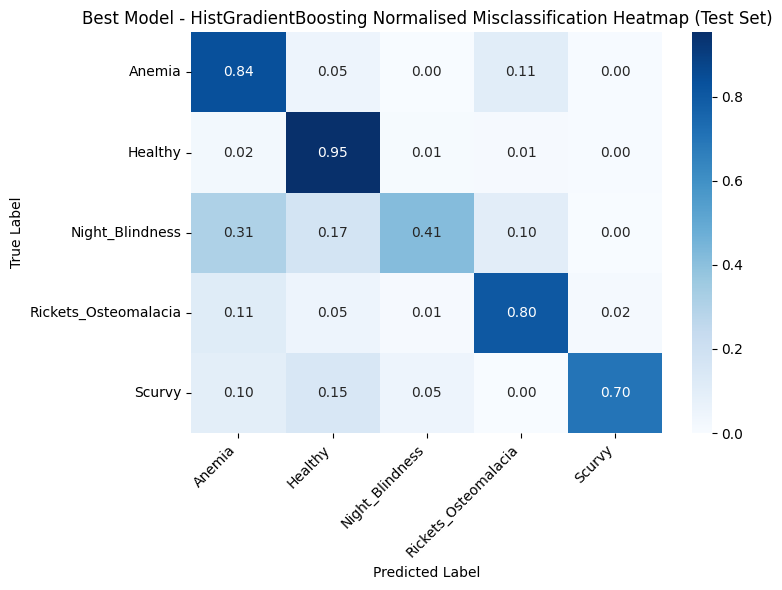

In [50]:
cm_test = confusion_matrix(y_test, y_test_pred_final, labels=best_hgb_final.classes_)
cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=best_hgb_final.classes_,
    yticklabels=best_hgb_final.classes_
)
plt.title("Best Model - HistGradientBoosting Normalised Misclassification Heatmap (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
final_results_analysis = """
The HistGradientBoosting model achieves a test macro F1 of 0.7625, consistent
with the validation score of 0.7647, a gap of just 0.002, confirming the
model generalises reliably to unseen patient data.

Test Set Performance:
- Healthy: 0.92 F1, 0.95 recall - the model correctly clears 241 out of 253
  healthy patients, avoiding unnecessary vitamin interventions.
- Anemia: 0.83 F1, 0.84 recall - catches 180 out of 215 Anemia cases,
  enabling timely iron and B12 supplementation plans.
- Rickets: 0.82 F1, 0.80 recall - identifies 140 out of 174 Rickets cases,
  supporting vitamin D and calcium intake recommendations.
- Scurvy: 0.72 F1, 0.70 recall - catches 14 out of 20 cases, the best
  Scurvy result across all experiments. Enables targeted vitamin C plans.
- Night_Blindness: 0.52 F1, 0.41 recall - weakest class, 12 out of 29
  caught. Vitamin A plans will be recommended for identified cases but
  missed cases remain a concern.

Can this model be used for personalised vitamin intake plans?

For Healthy, Anemia and Rickets - yes, with supervision. The model performs
consistently above 0.80 F1 for these classes and the predictions are reliable
enough to inform a personalised supplementation plan. A clinician reviewing
the model's output would find it a useful first line screening tool.

For Scurvy, partially. The 0.70 recall means 30% of Scurvy patients are
missed. However the 0.74 precision means most positive Scurvy predictions
are correct and can confidently trigger a vitamin C supplementation plan.

For Night_Blindness, not yet reliable enough. Missing 59% of cases means
the model cannot be trusted to drive vitamin A supplementation plans
independently. Clinical review is essential for any Night_Blindness prediction.

Overall the model is suitable as a decision support tool for personalised
vitamin intake planning, particularly for the three most common conditions.
It should not replace clinical judgment but can significantly reduce the
diagnostic workload by correctly screening the majority of patients.
"""

In [52]:
print_tile(size="h2", key='final_results_analysis', value=final_results_analysis)